# ****Лабораторная работа №2****: ***Сегментация дорог с Аэрофотоснимков***

## Датасет

In [72]:
from pathlib import Path
from typing import Optional, List, Callable
import numpy as np
import torch
from torch.utils.data import Dataset
import tifffile
import random


class RoadsDataset(Dataset):
    def __init__(
        self,
        root: str,
        split: str = "train",
        image_transform: Optional[Callable] = None,
        mask_transform: Optional[Callable] = None,
        return_paths: bool = False,
        binarize_mask: bool = True,
    ):
        super().__init__()
        self.root = Path(root)
        self.split = split
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.return_paths = return_paths
        self.binarize_mask = binarize_mask

        self.images_dir = self.root / split
        self.masks_dir = self.root / f"{split}_labels"

        image_paths = sorted(self.images_dir.glob("*.tiff"))
        self.image_paths: List[Path] = []
        self.mask_map = {}

        for img_path in image_paths:
            mask_path = self.masks_dir / f"{img_path.stem}.tif"
            if mask_path.exists():
                self.image_paths.append(img_path)
                self.mask_map[img_path.stem] = mask_path

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        img_path = self.image_paths[idx]
        mask_path = self.mask_map[img_path.stem]

        image = tifffile.imread(str(img_path))
        mask = tifffile.imread(str(mask_path))

        if self.binarize_mask:
            if mask.ndim == 3:
                mask = mask[..., 0]
            mask = (mask > 0).astype(np.float32)

        if self.image_transform is not None:
            if self.split == "train":
                seed = random.randint(0, 2**32 - 1)
                torch.manual_seed(seed)
                image = self.image_transform(image)

                torch.manual_seed(seed)
                mask = self.mask_transform(mask) if self.mask_transform is not None else mask
            else:
                image = self.image_transform(image)
                if self.mask_transform is not None:
                    mask = self.mask_transform(mask)

        mask = mask.float()

        if self.return_paths:
            return image, mask, str(img_path)
        return image, mask

In [73]:
import torchvision.transforms as T

patch_size = 512
dataset_path = "roads_dataset/tiff"

train_image_transform = T.Compose([
    T.ToTensor(),
    T.RandomCrop(patch_size), 
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
])

train_mask_transform = T.Compose([
    T.ToTensor(),
    T.RandomCrop(patch_size),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
])

testval_image_transform = T.Compose([
    T.ToTensor()
])

testval_mask_transform = T.Compose([
    T.ToTensor()
])



# Датасеты
train_ds = RoadsDataset(root=dataset_path, split="train",
                        image_transform=train_image_transform,
                        mask_transform=train_mask_transform)

val_ds = RoadsDataset(root=dataset_path, split="val",
                      image_transform=testval_image_transform,
                      mask_transform=testval_mask_transform)

test_ds = RoadsDataset(root=dataset_path, split="test",
                       image_transform=testval_image_transform,
                       mask_transform=testval_mask_transform)

image, mask = train_ds[0]
print(f"Размер изображения: {image.shape}")
print(f"Размер маски: {mask.shape}")

print(f"Train размер: {len(train_ds)}")
print(f"Val размер: {len(val_ds)}")
print(f"Test размер: {len(test_ds)}")

Размер изображения: torch.Size([3, 512, 512])
Размер маски: torch.Size([1, 512, 512])
Train размер: 1108
Val размер: 14
Test размер: 49


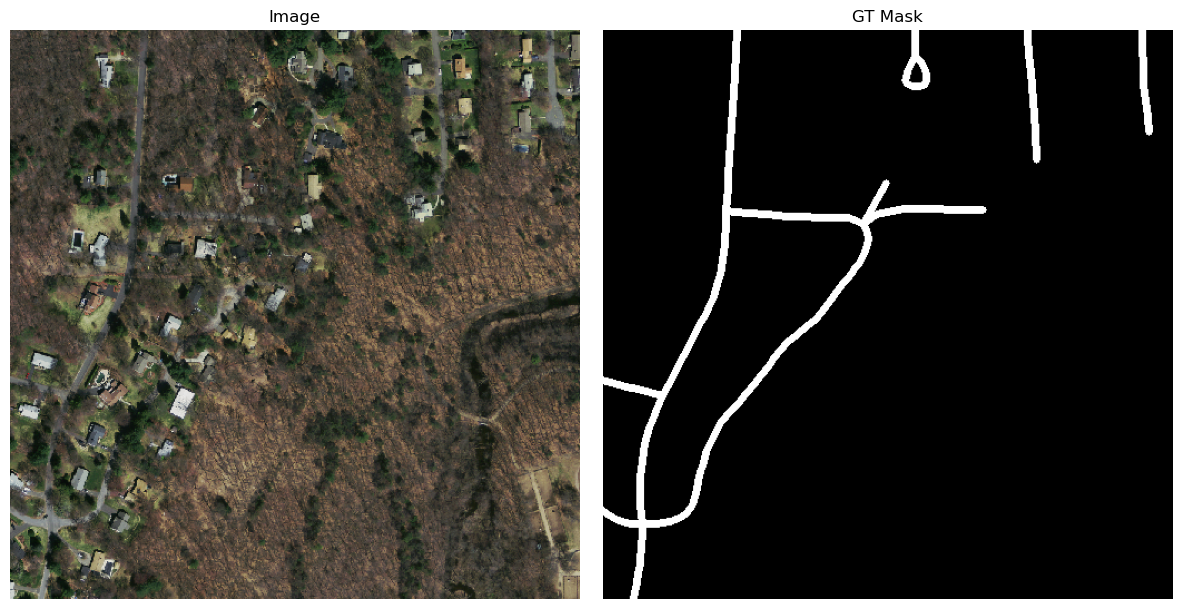

Image shape: torch.Size([3, 512, 512])
Mask shape: torch.Size([1, 512, 512])


In [74]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=4, shuffle=False)

images, masks = next(iter(train_loader))
image, mask = images[0], masks[0]


image_vis = image.permute(1, 2, 0).cpu().numpy()
mask_vis = mask.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_vis)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask_vis, cmap="gray")
axes[1].set_title("GT Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", image.shape if hasattr(image, "shape") else type(image))
print("Mask shape:", mask.shape if hasattr(mask, "shape") else type(mask))

# Модель, loss, optimizer

In [127]:
import torch
import torch.nn as nn
from tqdm import tqdm
import os

EPOCHS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"device: {DEVICE}")

device: cuda


In [128]:
import torch.optim as optim
from backboned_unet import Unet

model = Unet(
    backbone_name='vgg19', 
    pretrained=True, 
    encoder_freeze=False,
    classes=1,
    decoder_filters=(512, 256, 128, 64, 32)
).to(DEVICE)

print(model)


/home/v.skorikov/miniconda3/envs/pytorch-dl/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/v.skorikov/miniconda3/envs/pytorch-dl/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


upsample_blocks[0] in: 512   out: 512
upsample_blocks[1] in: 512   out: 256
upsample_blocks[2] in: 256   out: 128
upsample_blocks[3] in: 128   out: 64
upsample_blocks[4] in: 64   out: 32
Unet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, mome

In [129]:
import segmentation_models_pytorch as smp

criterion = smp.losses.DiceLoss(mode="binary", from_logits=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5, 
    patience=5
)

In [130]:
def dice_metric(tp, fp, fn):
    tp_sum = tp.sum()
    fp_sum = fp.sum()
    fn_sum = fn.sum()
        
    if tp_sum == 0 and fp_sum == 0 and fn_sum == 0:
        dice_score = 1.0
    else:
        dice_score = ((2.0 * tp_sum + 1e-7) / (2.0 * tp_sum + fp_sum + fn_sum + 1e-7)).item()
        
    return dice_score

def iou_metric(tp, fp, fn):
    tp_sum = tp.sum()
    fp_sum = fp.sum()
    fn_sum = fn.sum()
        
    if tp_sum == 0 and fp_sum == 0 and fn_sum == 0:
        iou_score = 1.0
    else:
        iou_score = ((tp_sum + 1e-7) / (tp_sum + fp_sum + fn_sum + 1e-7)).item()
        
    return iou_score

# Train цикл

In [131]:
import torch.nn.functional as F

def predict_sliding_window(model, image, patch_size=512, stride=256):
    B, C, H, W = image.shape
    
    preds = torch.zeros((B, 1, H, W), device=image.device)
    counts = torch.zeros((B, 1, H, W), device=image.device)
    
    for y in range(0, H, stride):
        for x in range(0, W, stride):
            
            y1 = min(y, max(0, H - patch_size))
            x1 = min(x, max(0, W - patch_size))
            y2 = min(y1 + patch_size, H)
            x2 = min(x1 + patch_size, W)
            
            patch = image[:, :, y1:y2, x1:x2]
            
            pad_h = patch_size - patch.shape[2]
            pad_w = patch_size - patch.shape[3]
            if pad_h > 0 or pad_w > 0:
                patch = F.pad(patch, (0, pad_w, 0, pad_h))
            
            logits = model(patch)
            
            if pad_h > 0 or pad_w > 0:
                logits = logits[:, :, :patch.shape[2], :patch.shape[3]]
            
            preds[:, :, y1:y2, x1:x2] += logits
            counts[:, :, y1:y2, x1:x2] += 1
            
    output = preds / torch.clamp(counts, min=1)
    return output


def train_epoch():
    model.train()
    running_loss = 0.0
    
    for images, masks in tqdm(train_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    return running_loss / len(train_loader)

@torch.no_grad()
def validate():
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    for images, masks in tqdm(val_loader, desc="Validation", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        
        logits = predict_sliding_window(model, images, patch_size=512, stride=256)
        loss = criterion(logits, masks)
        
        running_loss += loss.item()
        
        probs = torch.sigmoid(logits)
        tp, fp, fn, tn = smp.metrics.get_stats(probs, masks.long(), mode='binary', threshold=0.5)
        dice_score = dice_metric(tp, fp, fn)
        iou_score = iou_metric(tp, fp, fn)
        
        running_dice += dice_score
        running_iou += iou_score
        
    avg_loss = running_loss / len(val_loader)
    avg_dice = running_dice / len(val_loader)
    avg_iou = running_iou / len(val_loader)
    
    return avg_loss, avg_dice, avg_iou


In [132]:
best_dice = 0.0
best_epoch = 0

for epoch in range(EPOCHS):
    train_loss = train_epoch()
    val_loss, val_dice, val_iou = validate()
    
    scheduler.step(val_dice)

    print(f"Epoch {epoch+1:3d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Dice: {val_dice:.4f} | "
          f"Val IoU: {val_iou:.4f}")
    
    if val_dice > best_dice:
        best_dice = val_dice
        print(f"Обновлен best_dice: {best_dice} (IoU = {val_iou:.4f})", "\n")
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'dice': best_dice,
            'iou': val_iou
        }, os.path.join(SAVE_DIR, "best_unet.pth"))

print(f"\nЛучший Dice на валидации = {best_dice:.4f} (эпоха {best_epoch})")

100%|██████████| 139/139 [01:12<00:00,  1.91it/s]


Epoch   1 | Train Loss: 0.7502 | Val Loss: 0.5525 | Val Dice: 0.6485 | Val IoU: 0.4800
Обновлен best_dice: 0.6485120803117752 (IoU = 0.4800) 



100%|██████████| 139/139 [01:12<00:00,  1.91it/s]


Epoch   2 | Train Loss: 0.4753 | Val Loss: 0.4566 | Val Dice: 0.5585 | Val IoU: 0.3886


100%|██████████| 139/139 [01:12<00:00,  1.92it/s]


...

Epoch  48 | Train Loss: 0.2805 | Val Loss: 0.2189 | Val Dice: 0.7812 | Val IoU: 0.6414
Обновлен best_dice: 0.781235471367836 (IoU = 0.6414) 



100%|██████████| 139/139 [01:11<00:00,  1.94it/s]


Epoch  49 | Train Loss: 0.2835 | Val Loss: 0.2231 | Val Dice: 0.7771 | Val IoU: 0.6359


100%|██████████| 139/139 [01:11<00:00,  1.93it/s]
                                                         

Epoch  50 | Train Loss: 0.2781 | Val Loss: 0.2220 | Val Dice: 0.7781 | Val IoU: 0.6372

Лучший Dice на валидации = 0.7812 (эпоха 48)


# Тест

/tmp/ipykernel_219743/2367613631.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE)


Веса загружены (Эпоха 48, Dice на валидации: 0.7812)


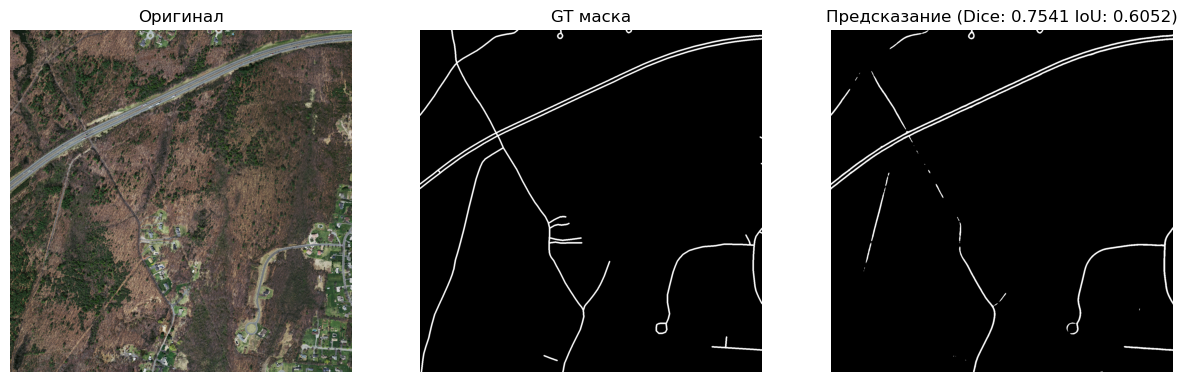

Avg Dice Score на тесте: 0.7955
Avg IoU Score на тесте: 0.6614


In [134]:
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F
import segmentation_models_pytorch as smp

checkpoint_path = os.path.join(SAVE_DIR, "best_unet.pth")
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
epoch_saved = checkpoint.get('epoch', 'N/A')
dice_saved = checkpoint.get('dice', 0.0)
print(f"Веса загружены (Эпоха {epoch_saved}, Dice на валидации: {dice_saved:.4f})")


model.eval()
test_dice = 0
test_iou = 0
num_samples = 0

patch_size = 512
stride = 256

with torch.no_grad():
    for i, (image, mask) in enumerate(test_loader):
        image = image.to(DEVICE)
        mask = mask.to(DEVICE)
        
        # Используем общую функцию из блока Train!
        output = predict_sliding_window(model, image, patch_size=patch_size, stride=stride)
        
        loss = criterion(output, mask)
        
        probs = torch.sigmoid(output)
        tp, fp, fn, tn = smp.metrics.get_stats(probs, mask.long(), mode='binary', threshold=0.5)
        dice_score = dice_metric(tp, fp, fn)
        iou_score = iou_metric(tp, fp, fn)
        
        test_dice += dice_score
        test_iou += iou_score
        num_samples += 1
        
        if i == 0:
            img_vis = image[0].permute(1, 2, 0).cpu().numpy()
            gt_vis = mask[0].squeeze().cpu().numpy()
            pred_vis = (probs[0].squeeze() > 0.5).cpu().numpy()
            
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(img_vis)
            axes[0].set_title("Оригинал")
            axes[0].axis("off")

            axes[1].imshow(gt_vis, cmap="gray")
            axes[1].set_title("GT маска")
            axes[1].axis("off")

            axes[2].imshow(pred_vis, cmap="gray")
            axes[2].set_title(f"Предсказание (Dice: {test_dice:.4f} IoU: {test_iou:.4f})")
            axes[2].axis("off")
            plt.show()

avg_test_dice = test_dice / max(1, num_samples)
avg_test_iou = test_iou / max(1, num_samples)
print(f'Avg Dice Score на тесте: {avg_test_dice:.4f}')
print(f'Avg IoU Score на тесте: {avg_test_iou:.4f}')